# Dubins — bounded additive-noise robustness sweep

Empirical companion to the robustness _Remark_ (reply **AE/R2** on bounded
disturbances): the closed-loop reach-avoid success rate \(\rho\) degrades
**smoothly** as the additive-disturbance bound \(D\) grows.

The plant evolves under \(\dot x = f(x) + g(x)\,u + w\) with \(w\) held
constant over each sampling interval and \(\lVert w_i\rVert \le D\cdot
\text{NOISE_SCALE}\_i\). The RA-MPC controller plans **nominally** (it does not
see \(w\)), so this measures the realised robustness of the nominal scheme.
\(D=0\) reproduces the nominal `feas_rampc`, anchoring \(\rho(0)\) to the
paper's figure. Setup (dynamics, sets, MPC) is identical to
`make_paper_figs_dubins.ipynb`; the \(\rho\)-vs-\(D\) figure reuses that
notebook's success-rate panel style.


In [1]:
# ── Repo-root bootstrap ───────────────────────────────────────────────────────
import os
import sys

ROOT = os.getcwd()
for _ in range(4):
    if os.path.isdir(os.path.join(ROOT, "controllers")) and os.path.isdir(
        os.path.join(ROOT, "matlab")
    ):
        break
    ROOT = os.path.dirname(ROOT)
for _sub in ("controllers", "python"):
    _p = os.path.join(ROOT, _sub)
    if _p not in sys.path:
        sys.path.insert(0, _p)
OUTDIR = os.path.join(ROOT, "figures")
os.makedirs(OUTDIR, exist_ok=True)
print("ROOT  =", ROOT)
print("OUTDIR=", OUTDIR)

ROOT  = /Users/jianqiang/Downloads/reach_avoid_backstepping_MPC
OUTDIR= /Users/jianqiang/Downloads/reach_avoid_backstepping_MPC/figures


In [ ]:
# ── Parameters (bounded additive-noise robustness sweep) ──────────────────────
NOISE_SWEEP = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4]  # disturbance bounds D
NOISE_SCALE = [
    1.0,
    1.0,
    1.0,
    1.0,
]  # per-channel weights on [x1_dot, x2_dot, th_dot, v_dot]
N_NOISE_CAND = 100  # candidate initial conditions (subset of the shared pool)
N_NOISE_REALIZ = 1  # noise realisations averaged per IC (raise to smooth rho)
RECOMPUTE = False  # True to ignore the cached sweep
DT_BASE, N_BASE = 0.05, 25
T_MAX = 20.0  # closed-loop reach-avoid window [s]
SEED = 42  # MUST match make_paper_figs_dubins.ipynb so ICs / D=0 align
N_CANDIDATES = 300  # same candidate pool as the paper figures

In [3]:
# ── Load controllers + symbols / dynamics / sets (same as the example notebooks)
import numpy as np
import sympy as sp
import casadi as ca
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

from sop_bounded_control_dubins_car_result import certificate_opt, k1_opt as k1_ra
from sop_bounded_control_dubins_car_unconstrained import (
    u_opt as u_unc,
    k1_opt as k1_unc,
)

x1, x2, th, v = sp.symbols("x1 x2 th v")
y1, y2 = sp.symbols("y1 y2")
state_vars = [x1, x2, th, v]
f_sym = sp.Matrix([v * sp.cos(th), v * sp.sin(th), 0, 0])
g_sym = sp.Matrix([[0, 0], [0, 0], [1, 0], [0, 1]])
hx = sp.Matrix([x1, x2])
h_raw = -(y1**4 + y2**4 - 16) * (y1**4 + y2**4 - 4)
target_set_y = (y2 - 0) ** 2 + (2 * (y1 + 1.7)) ** 2 - 0.4
alpha = 1e-3 * (-target_set_y + 300)
safe_set_y = alpha * h_raw
safe_set_x = safe_set_y.subs({y1: hx[0], y2: hx[1]})
target_set_x = target_set_y.subs({y1: hx[0], y2: hx[1]})
u_unc = sp.Matrix(u_unc)

safe_x_f = sp.lambdify(state_vars, safe_set_x, "numpy")
target_x_f = sp.lambdify(state_vars, target_set_x, "numpy")
u_unc_f = sp.lambdify(state_vars, list(u_unc), "numpy")
safe_y_f = sp.lambdify([y1, y2], safe_set_y, "numpy")
target_y_f = sp.lambdify([y1, y2], target_set_y, "numpy")

u1_max = u2_max = 5.0
U_MAX = (u1_max, u2_max)
TARGET_POS = np.array([-1.7, 0.0])
Q_y, Qf_y, R_u = 5.0, 80.0, 0.05
IPOPT = {
    "ipopt.print_level": 0,
    "print_time": 0,
    "ipopt.max_iter": 500,
    "ipopt.tol": 1e-4,
    "ipopt.acceptable_tol": 1e-3,
}
print("cert free symbols:", certificate_opt.free_symbols)

cert free symbols: {x1, x2, v, th}


In [4]:
# ── CasADi sets + parametric MPC (terminal = "target" for vanilla, "cert" for RA-MPC)
def _s2c(e, mp):
    if isinstance(
        e,
        (
            sp.Integer,
            sp.Float,
            sp.Rational,
            sp.core.numbers.NegativeOne,
            sp.core.numbers.Half,
            sp.core.numbers.One,
            sp.core.numbers.Zero,
            sp.core.numbers.Pi,
        ),
    ):
        return float(e)
    if isinstance(e, sp.Symbol):
        return mp[e]
    if isinstance(e, sp.Add):
        return sum(_s2c(a, mp) for a in e.args)
    if isinstance(e, sp.Mul):
        r = 1.0
        for a in e.args:
            r = r * _s2c(a, mp)
        return r
    if isinstance(e, sp.Pow):
        return _s2c(e.args[0], mp) ** _s2c(e.args[1], mp)
    if isinstance(e, sp.sin):
        return ca.sin(_s2c(e.args[0], mp))
    if isinstance(e, sp.cos):
        return ca.cos(_s2c(e.args[0], mp))
    if isinstance(e, sp.Number):
        return float(e)
    raise ValueError(type(e))


_cx = [ca.SX.sym(n) for n in ("x1", "x2", "th", "v")]
_mp = {x1: _cx[0], x2: _cx[1], th: _cx[2], v: _cx[3]}
cert_f = ca.Function("cert", _cx, [_s2c(certificate_opt, _mp)])
safe_cf = ca.Function("safe", _cx, [_s2c(safe_set_x, _mp)])
_uc = ca.SX.sym("u", 2)
_xs = ca.vertcat(*_cx)
fc_f = ca.Function(
    "fc",
    [_xs, _uc],
    [ca.vertcat(_cx[3] * ca.cos(_cx[2]), _cx[3] * ca.sin(_cx[2]), _uc[0], _uc[1])],
)


def safe_ca(x):
    return safe_cf(x[0], x[1], x[2], x[3])


def cert_ca(x):
    return cert_f(x[0], x[1], x[2], x[3])


def target_ca(x):
    return (x[1]) ** 2 + (2 * (x[0] + 1.7)) ** 2 - 0.4


def _rk4(step_fn, xk, uk, dt):
    k1 = step_fn(xk, uk)
    k2 = step_fn(xk + dt / 2 * k1, uk)
    k3 = step_fn(xk + dt / 2 * k2, uk)
    k4 = step_fn(xk + dt * k3, uk)
    return xk + (dt / 6) * (k1 + 2 * k2 + 2 * k3 + k4)


def rk4_np(x, u, dt):
    def f(xx):
        return np.array([xx[3] * np.cos(xx[2]), xx[3] * np.sin(xx[2]), u[0], u[1]])

    return _rk4(lambda xx, uu: f(xx), np.asarray(x, float), u, dt)


def zoh_step(x, u, dt):
    """Advance the TRUE continuous dynamics over [0, dt] under the constant (ZOH)
    control u, via fine RK4 substeps. This is the realistic sampled closed-loop
    step: the MPC plans with the coarse-dt model but the plant evolves continuously,
    so coarser sampling (larger dt) incurs a real model mismatch."""
    nsub = max(1, int(round(dt / 0.005)))
    h = dt / nsub
    x = np.asarray(x, float)
    for _ in range(nsub):
        x = rk4_np(x, u, h)
    return x


import time as _time

SOLVE_MS = {
    "target": [],
    "cert": [],
}  # per-step opti.solve() wall times [ms], by terminal


def solve_mpc(x0, terminal, dt=DT_BASE, N=N_BASE, U_warm=None):
    opti = ca.Opti()
    X = opti.variable(4, N + 1)
    U = opti.variable(2, N)
    x0 = np.asarray(x0, float).flatten()
    opti.subject_to(X[:, 0] == x0)
    for k in range(N):
        opti.subject_to(X[:, k + 1] == _rk4(fc_f, X[:, k], U[:, k], dt))
        opti.subject_to(safe_ca(X[:, k]) >= 0)
    opti.subject_to(safe_ca(X[:, N]) >= 0)
    if terminal == "target":
        opti.subject_to(target_ca(X[:, N]) <= 0)
    else:
        opti.subject_to(cert_ca(X[:, N]) >= 0)
    opti.subject_to(opti.bounded(-u1_max, U[0, :], u1_max))
    opti.subject_to(opti.bounded(-u2_max, U[1, :], u2_max))
    tgt = ca.DM(TARGET_POS)
    cost = 0
    for k in range(N):
        dy = X[:2, k] - tgt
        cost += Q_y * ca.dot(dy, dy) + R_u * ca.dot(U[:, k], U[:, k])
    dyN = X[:2, N] - tgt
    cost += Qf_y * ca.dot(dyN, dyN)
    opti.minimize(cost)
    if U_warm is not None and U_warm.shape[1] == N:
        Uws = np.hstack([U_warm[:, 1:], U_warm[:, -1:]])
        Xws = np.zeros((4, N + 1))
        Xws[:, 0] = x0
        for k in range(N):
            Xws[:, k + 1] = rk4_np(Xws[:, k], Uws[:, k], dt)
        opti.set_initial(X, Xws)
        opti.set_initial(U, Uws)
    else:
        tgt_full = np.array([TARGET_POS[0], TARGET_POS[1], x0[2], 0.0])
        Xws = np.array([(1 - k / N) * x0 + (k / N) * tgt_full for k in range(N + 1)]).T
        opti.set_initial(X, Xws)
        opti.set_initial(U, 0)
    opti.solver("ipopt", IPOPT)
    try:
        _t0 = _time.perf_counter()
        sol = opti.solve()
        SOLVE_MS.setdefault(terminal, []).append((_time.perf_counter() - _t0) * 1000.0)
        return (
            True,
            np.array(sol.value(U)).reshape(2, N),
            np.array(sol.value(X)).reshape(4, N + 1),
        )
    except Exception:
        return False, None, None

In [ ]:
# ── Bounded additive-noise plant step + RA-MPC success predicate ─────────────
def rk4_np_noisy(x, u, w, dt):
    def f(xx):
        return np.array([xx[3] * np.cos(xx[2]), xx[3] * np.sin(xx[2]), u[0], u[1]]) + w

    return _rk4(lambda xx, uu: f(xx), np.asarray(x, float), u, dt)


def zoh_step_noisy(x, u, w, dt):
    """True continuous plant over [0, dt] under the constant (ZOH) control u and a
    constant additive disturbance w held over the sampling interval, via fine RK4
    substeps."""
    nsub = max(1, int(round(dt / 0.005)))
    h = dt / nsub
    x = np.asarray(x, float)
    for _ in range(nsub):
        x = rk4_np_noisy(x, u, w, h)
    return x


def feas_rampc_noisy(x0, D, seed, dt=DT_BASE, N=N_BASE, T_max=T_MAX, scale=None):
    """Closed-loop RA-MPC rollout under a bounded additive disturbance of bound D.
    Success = the trajectory reaches X_T while staying in X_S throughout. The
    controller is nominal (plans without w); only the plant is disturbed. D = 0
    reproduces the nominal feas_rampc exactly."""
    rng = np.random.default_rng(seed)
    scale = np.ones(4) if scale is None else np.asarray(scale, float)
    x = np.asarray(x0, float).copy()
    U_prev = None
    for _ in range(int(round(T_max / dt))):
        if float(np.squeeze(safe_x_f(*x))) < 0:
            return False
        if float(np.squeeze(target_x_f(*x))) <= 0:
            return True
        ok, U, _ = solve_mpc(x, "cert", dt=dt, N=N, U_warm=U_prev)
        if not ok:
            return False
        U_prev = U
        w = scale * rng.uniform(-D, D, size=4)
        x = zoh_step_noisy(x, U[:, 0], w, dt)
        if not np.all(np.isfinite(x)):
            return False
    return bool(float(np.squeeze(target_x_f(*x))) <= 0)

In [ ]:
# ── Shared candidate ICs (identical pool to make_paper_figs_dubins) ───────────
np.random.seed(SEED)
lb = np.array([-2.0, -2.0, 2 * np.pi / 3, -1.0])
ub = np.array([2.0, 2.0, 4 * np.pi / 3, 1.0])
X = np.random.rand(4, 1000) * (ub - lb).reshape(-1, 1) + lb.reshape(-1, 1)
_safe = np.atleast_1d(np.squeeze(safe_x_f(*X)))
_tgt = np.atleast_1d(np.squeeze(target_x_f(*X)))
candidate_idx = np.where((_safe >= 0) & (_tgt > 0))[0][:N_CANDIDATES]
noise_idx = candidate_idx[:N_NOISE_CAND]
print(f"candidates (safe & outside target): {len(candidate_idx)}")
print(f"noise-sweep subset: {len(noise_idx)} ICs")

candidates (safe & outside target): 300
noise-sweep subset: 100 ICs


In [7]:
# ── Noise sweep: rho(D) over the candidate ICs (cached) ─────────────────
from joblib import Parallel, delayed
import hashlib


def _noise_sig():
    parts = [
        "noise-zoh",
        N_NOISE_CAND,
        N_NOISE_REALIZ,
        SEED,
        DT_BASE,
        N_BASE,
        T_MAX,
        tuple(NOISE_SWEEP),
        tuple(NOISE_SCALE),
        u1_max,
        u2_max,
        int(
            os.path.getmtime(
                os.path.join(
                    ROOT, "controllers", "sop_bounded_control_dubins_car_result.py"
                )
            )
        ),
    ]
    return hashlib.md5(repr(parts).encode()).hexdigest()


def _ic_success(ic, D, di):
    reps = [
        feas_rampc_noisy(
            X[:, ic], D, seed=SEED + 9973 * di + 31 * int(ic) + r, scale=NOISE_SCALE
        )
        for r in range(N_NOISE_REALIZ)
    ]
    return float(np.mean(reps))


_ncache = os.path.join(OUTDIR, "noise_sweep_cache.npz")
noise_rho = None
if (not RECOMPUTE) and os.path.exists(_ncache):
    d = np.load(_ncache)  # self-written cache; plain arrays + string sig
    if str(d["sig"]) == _noise_sig():
        noise_D, noise_rho = d["D"], d["rho"]
        print("loaded cached noise sweep")

if noise_rho is None:
    print(
        f"computing noise sweep: {len(noise_idx)} ICs x {len(NOISE_SWEEP)} bounds "
        f"x {N_NOISE_REALIZ} realiz ..."
    )
    noise_D, noise_rho = [], []
    for di, D in enumerate(NOISE_SWEEP):
        s = Parallel(n_jobs=-1, prefer="processes")(
            delayed(_ic_success)(int(ic), D, di) for ic in noise_idx
        )
        rho = 100.0 * float(np.mean(s))
        noise_D.append(D)
        noise_rho.append(rho)
        print(f"  D={D:.3f}  rho={rho:.1f}%")
    noise_D, noise_rho = np.array(noise_D), np.array(noise_rho)
    np.savez(_ncache, sig=_noise_sig(), D=noise_D, rho=noise_rho)

computing noise sweep: 100 ICs x 8 bounds x 1 realiz ...

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is 

saved fig_dubins_noise


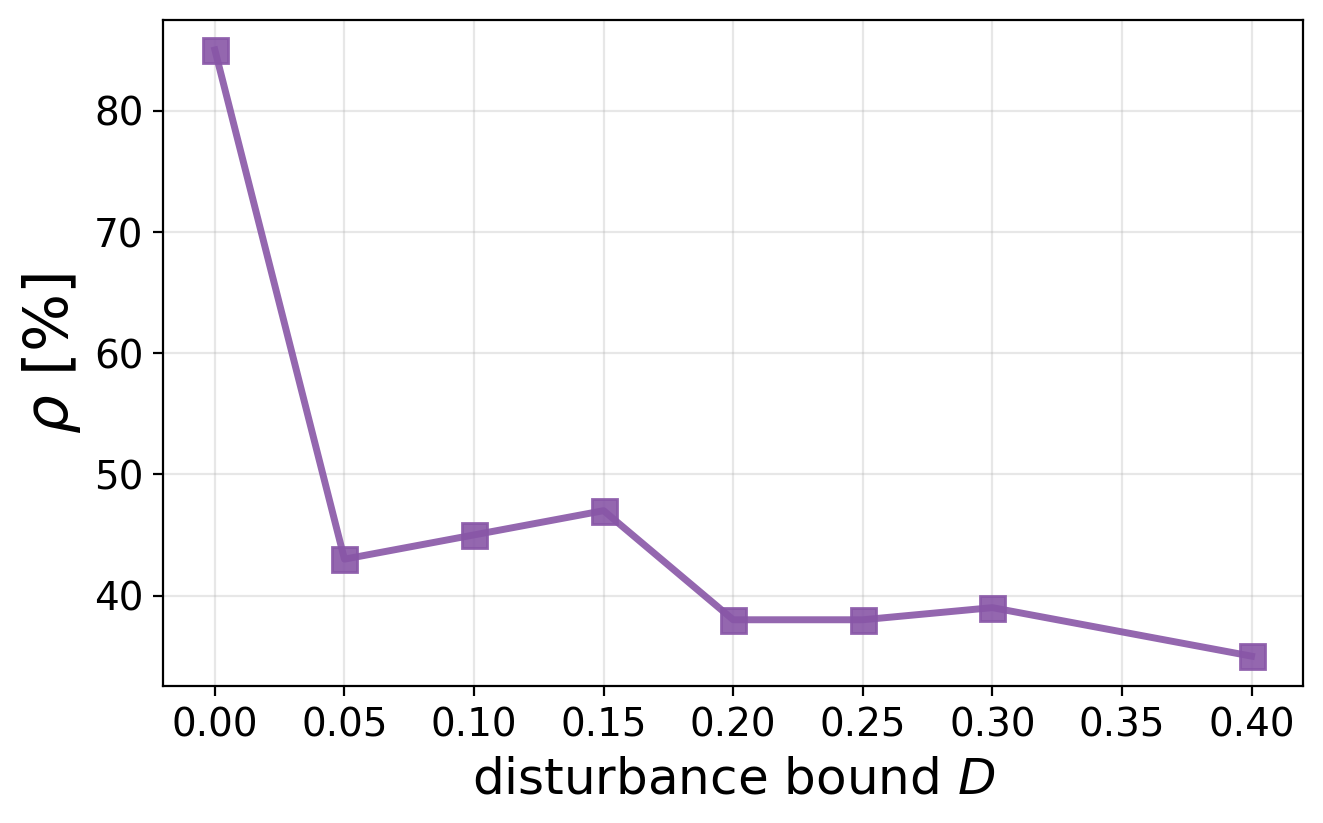

In [8]:
# ── Figure: rho vs disturbance bound D (style matches the dt-sweep rho panel) ──
px = 1 / plt.rcParams["figure.dpi"]
FS_C = 24

fig, ax = plt.subplots(figsize=(650 * px, 400 * px), layout="constrained")
fig.set_dpi(200)
ax.plot(
    noise_D,
    noise_rho,
    color="#8856a7",
    marker="s",
    lw=2.5,
    ms=9,
    alpha=0.9,
    label="RA-MPC (ours)",
)
ax.set_xlabel(r"disturbance bound $D$", fontsize=FS_C - 6)
ax.set_ylabel(r"$\rho$ [%]", fontsize=FS_C - 2)
ax.xaxis.set_tick_params(labelsize=14)
ax.yaxis.set_tick_params(labelsize=14)
ax.grid(True, alpha=0.3)

for ext in ("pdf", "png"):
    fig.savefig(os.path.join(OUTDIR, f"fig_dubins_noise.{ext}"), dpi=200)
print("saved fig_dubins_noise")
plt.show()